# 非线性系统回归预测模型训练

## 任务：多输入多输出非线性系统映射学习
## 架构：MLP（多层感知机） + LSTM（时序记忆网络）
## 目标：R² ≥ 0.50


In [1]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, os, sys
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns

# Auto-detect project root
def get_project_root():
    current = os.path.abspath(os.getcwd())
    for _ in range(5):
        if os.path.exists(os.path.join(current, 'backend')) and os.path.exists(os.path.join(current, 'dataset')):
            return current
        parent = os.path.dirname(current)
        if parent == current: break
        current = parent
    return os.getcwd()
ROOT = get_project_root()
print(f'Project root: {ROOT}')

sys.path.insert(0, os.path.join(ROOT, 'backend', 'regression_model'))
from model import get_model

import warnings as _w; _w.filterwarnings('ignore', category=UserWarning)
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Project root: C:\Users\DOVE\python学习\大二下实训
Device: cuda


X: (5000, 3), Y: (5000, 3)


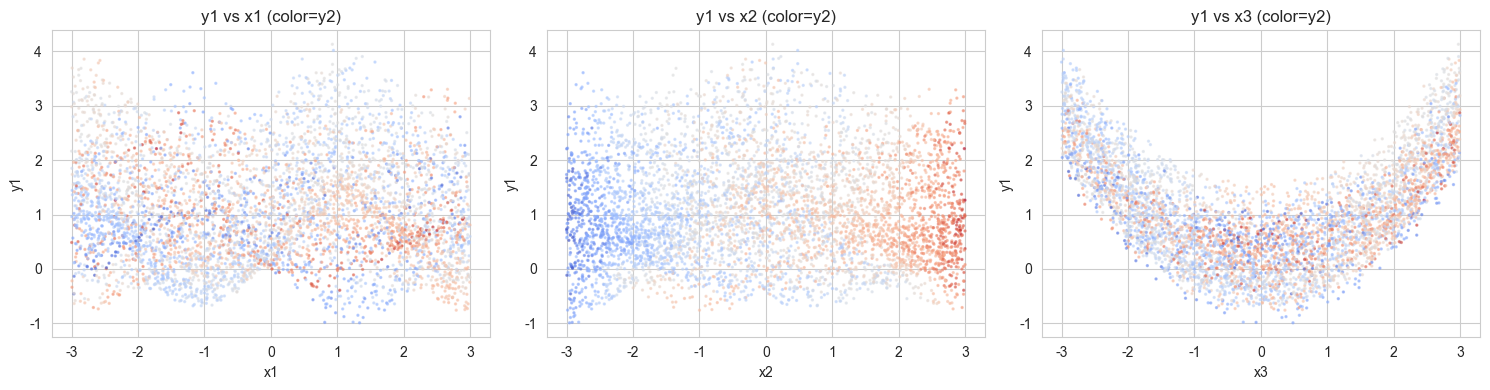

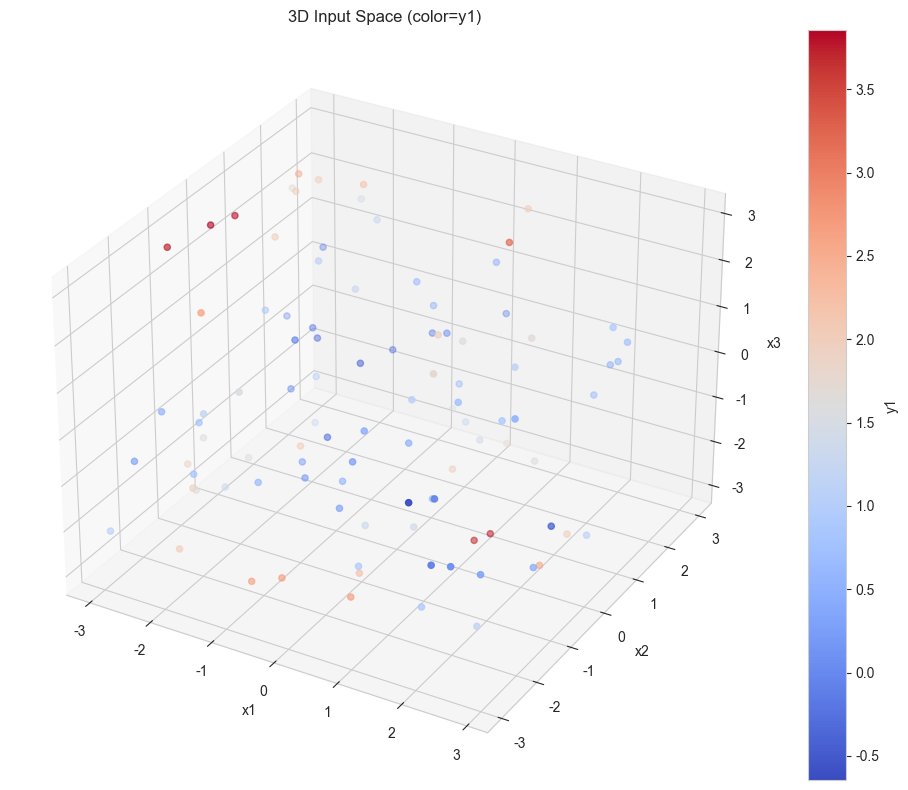

In [12]:
# ==================== 1. 生成合成非线性数据 ====================
np.random.seed(42); N = 5000
x1 = np.random.uniform(-3, 3, N); x2 = np.random.uniform(-3, 3, N); x3 = np.random.uniform(-3, 3, N)
y1 = np.sin(x1*1.5)*np.cos(x2*0.8) + x3**2*0.3 + np.exp(-np.abs(x2))*0.5 + np.sin(x1*x2*0.3)*0.4
y2 = np.cos(x3*1.2)*np.sin(x1*0.7) + x2**3*0.1 + np.tanh(x1+x2+x3)*0.6
y3 = np.sin(x1+x2)*np.cos(x3)*0.8 + np.abs(x1*x3)*0.15 + x2**2*0.2 + np.cos(x1*x2*x3*0.1)*0.3
for y in [y1,y2,y3]: y += np.random.normal(0, 0.05, N)
X = np.stack([x1,x2,x3],1).astype(np.float32); Y = np.stack([y1,y2,y3],1).astype(np.float32)
print(f'X: {X.shape}, Y: {Y.shape}')

# 数据可视化
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (ax, xi) in enumerate(zip(axes, [x1,x2,x3])):
    ax.scatter(xi, y1, c=y2, cmap='coolwarm', s=2, alpha=0.5)
    ax.set_xlabel(f'x{i+1}'); ax.set_ylabel(f'y1')
    ax.set_title(f'y1 vs x{i+1} (color=y2)')
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'regression_model', 'checkpoints', '01_data_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

# 3D可视化
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x1[::50], x2[::50], x3[::50], c=y1[::50], cmap='coolwarm', s=20)
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('x3')
ax.set_title('3D Input Space (color=y1)'); plt.colorbar(sc, label='y1')
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'regression_model', 'checkpoints', '01_3d_input.png'), dpi=150, bbox_inches='tight')
plt.show()


In [3]:
# ==================== 2. 数据预处理 ====================
scaler_X = StandardScaler(); scaler_Y = StandardScaler()
Xs = scaler_X.fit_transform(X); Ys = scaler_Y.fit_transform(Y)
X_tr, X_tmp, Y_tr, Y_tmp = train_test_split(Xs, Ys, test_size=0.3, random_state=42)
X_v, X_te, Y_v, Y_te = train_test_split(X_tmp, Y_tmp, test_size=0.5, random_state=42)
print(f'Train: {len(X_tr)} | Val: {len(X_v)} | Test: {len(X_te)}')

BATCH = 64
tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(Y_tr)), BATCH, True)
v_loader  = DataLoader(TensorDataset(torch.tensor(X_v), torch.tensor(Y_v)), BATCH, False)
te_loader  = DataLoader(TensorDataset(torch.tensor(X_te), torch.tensor(Y_te)), BATCH, False)


Train: 3500 | Val: 750 | Test: 750


In [4]:
# ==================== 3. 训练 MLP 回归器 ====================
print('=== MLP Regressor (3->128->128->64->3) ===')
mlp_r = get_model('mlp', 3, 3).to(DEVICE)
crit = nn.MSELoss(); opt = optim.Adam(mlp_r.parameters(), lr=0.001)
sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=10, factor=0.5)

hist_mlp = {'train_loss':[], 'val_loss':[]}
best_loss, best_st, wait = float('inf'), None, 0
for ep in range(200):
    mlp_r.train(); tl=0
    for x,y in tr_loader:
        x,y=x.to(DEVICE),y.to(DEVICE); opt.zero_grad()
        loss=crit(mlp_r(x),y); loss.backward(); opt.step(); tl+=loss.item()
    tl/=len(tr_loader)
    mlp_r.eval(); vl=0
    with torch.no_grad():
        for x,y in v_loader: x,y=x.to(DEVICE),y.to(DEVICE); vl+=crit(mlp_r(x),y).item()
    vl/=len(v_loader); sched.step(vl)
    hist_mlp['train_loss'].append(tl); hist_mlp['val_loss'].append(vl)
    if vl<best_loss: best_loss=vl; best_st={k:v.cpu().clone() for k,v in mlp_r.state_dict().items()}; wait=0
    else: wait+=1
    if wait>=40: print(f'MLP early stop at {ep+1}'); break
    if (ep+1)%20==0: print(f'[MLP] E{ep+1:3d} | TL={tl:.4f} VL={vl:.4f}')
mlp_r.load_state_dict(best_st)

# Test R²
mlp_r.eval(); preds_mlp, truths = [], []
with torch.no_grad():
    for x,y in te_loader: x=x.to(DEVICE); preds_mlp.append(mlp_r(x).cpu().numpy()); truths.append(y.numpy())
preds_mlp = np.concatenate(preds_mlp); truths = np.concatenate(truths)
r2_mlp = r2_score(truths, preds_mlp, multioutput='uniform_average')
mse_mlp = mean_squared_error(truths, preds_mlp)
print(f'MLP Test R²={r2_mlp:.4f}, MSE={mse_mlp:.4f}')


=== MLP Regressor (3->128->128->64->3) ===
[MLP] E 20 | TL=0.0879 VL=0.0364
[MLP] E 40 | TL=0.0679 VL=0.0246
[MLP] E 60 | TL=0.0517 VL=0.0198
[MLP] E 80 | TL=0.0489 VL=0.0174
[MLP] E100 | TL=0.0453 VL=0.0169
[MLP] E120 | TL=0.0463 VL=0.0143
[MLP] E140 | TL=0.0452 VL=0.0153
MLP early stop at 160
MLP Test R²=0.9870, MSE=0.0125


In [5]:
# ==================== 4. 训练 LSTM 回归器（同一 3→3 数据） ====================
# LSTM 将 3 个输入特征视为序列 (seq_len=3, feature=1)
# 通过循环结构捕获特征间的交互依赖，再映射到 3 维输出
print('=== LSTM Regressor (3→3, seq view) ===')

# 将静态数据 reshape 为序列：(N, 3) → (N, 3, 1)
X_tr_seq = torch.tensor(X_tr).unsqueeze(-1)   # (N, 3, 1)
X_v_seq  = torch.tensor(X_v).unsqueeze(-1)
X_te_seq = torch.tensor(X_te).unsqueeze(-1)
Y_tr_t   = torch.tensor(Y_tr)
Y_v_t    = torch.tensor(Y_v)
Y_te_t   = torch.tensor(Y_te)

tr_loader_l = DataLoader(TensorDataset(X_tr_seq, Y_tr_t), BATCH, True)
v_loader_l  = DataLoader(TensorDataset(X_v_seq, Y_v_t), BATCH, False)
te_loader_l  = DataLoader(TensorDataset(X_te_seq, Y_te_t), BATCH, False)

# 训练 LSTM（output_dim=3，和 MLP 一样的三输出）
lstm_r = get_model('lstm', input_dim=1, output_dim=3).to(DEVICE)
crit_l = nn.MSELoss()
opt_l = optim.Adam(lstm_r.parameters(), lr=0.001)
sched_l = optim.lr_scheduler.ReduceLROnPlateau(opt_l, mode='min', patience=10, factor=0.5)

hist_lstm = {'train_loss':[], 'val_loss':[]}
best_loss_l, best_st_l, wait_l = float('inf'), None, 0
for ep in range(200):
    lstm_r.train(); tl = 0
    for x, y in tr_loader_l:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt_l.zero_grad()
        loss = crit_l(lstm_r(x), y); loss.backward(); opt_l.step()
        tl += loss.item()
    tl /= len(tr_loader_l)

    lstm_r.eval(); vl = 0
    with torch.no_grad():
        for x, y in v_loader_l:
            x, y = x.to(DEVICE), y.to(DEVICE)
            vl += crit_l(lstm_r(x), y).item()
    vl /= len(v_loader_l); sched_l.step(vl)

    hist_lstm['train_loss'].append(tl); hist_lstm['val_loss'].append(vl)
    if vl < best_loss_l:
        best_loss_l = vl
        best_st_l = {k: v.cpu().clone() for k, v in lstm_r.state_dict().items()}
        wait_l = 0
    else:
        wait_l += 1
    if wait_l >= 40:
        print(f'LSTM early stop at {ep+1}'); break
    if (ep + 1) % 20 == 0:
        print(f'[LSTM] E{ep+1:3d} | TL={tl:.4f} VL={vl:.4f}')

lstm_r.load_state_dict(best_st_l)

# —— Test R² & MSE（和 MLP 完全相同的评估） ——
lstm_r.eval(); preds_lstm, truths_l = [], []
with torch.no_grad():
    for x, y in te_loader_l:
        x = x.to(DEVICE)
        preds_lstm.append(lstm_r(x).cpu().numpy())
        truths_l.append(y.numpy())
preds_lstm = np.concatenate(preds_lstm); truths_l = np.concatenate(truths_l)

r2_lstm = r2_score(truths_l, preds_lstm, multioutput='uniform_average')
mse_lstm = mean_squared_error(truths_l, preds_lstm)
print(f'LSTM Test R²={r2_lstm:.4f}, MSE={mse_lstm:.4f}')


=== LSTM Regressor (3→3, seq view) ===
[LSTM] E 20 | TL=0.0274 VL=0.0132
[LSTM] E 40 | TL=0.0184 VL=0.0080
[LSTM] E 60 | TL=0.0158 VL=0.0076
[LSTM] E 80 | TL=0.0142 VL=0.0068
[LSTM] E100 | TL=0.0118 VL=0.0060
[LSTM] E120 | TL=0.0112 VL=0.0058
[LSTM] E140 | TL=0.0104 VL=0.0055
[LSTM] E160 | TL=0.0100 VL=0.0051
[LSTM] E180 | TL=0.0101 VL=0.0051
[LSTM] E200 | TL=0.0098 VL=0.0049
LSTM Test R²=0.9954, MSE=0.0044


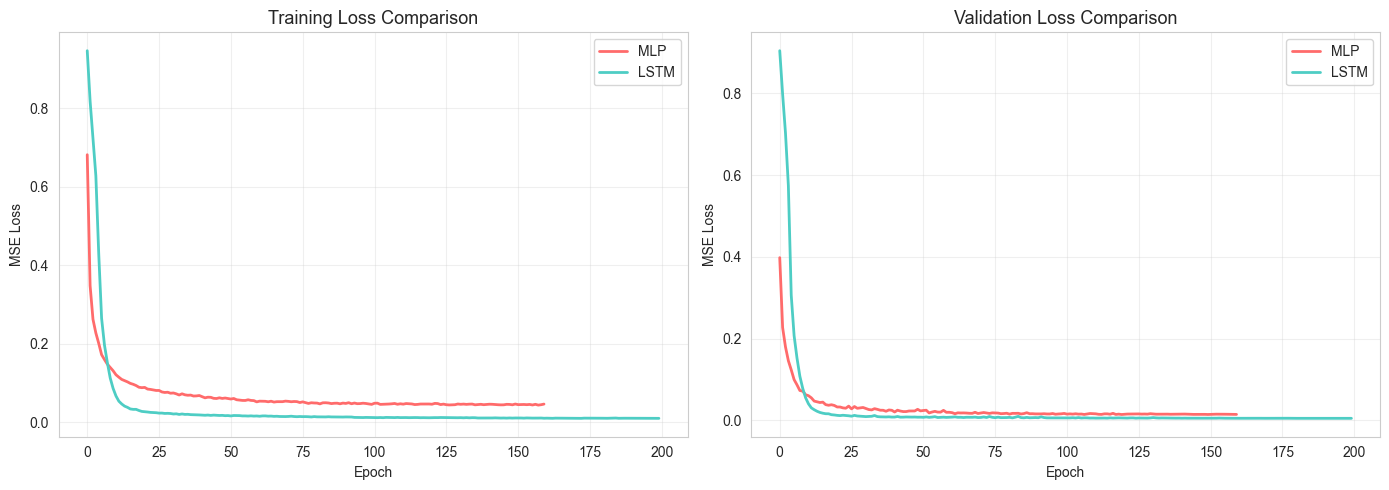

In [6]:
# ==================== 5. 训练Loss曲线对比 ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, key, title in [(axes[0], 'train_loss', 'Training Loss'), (axes[1], 'val_loss', 'Validation Loss')]:
    ax.plot(hist_mlp[key], label='MLP', color='#FF6B6B', linewidth=2)
    ax.plot(hist_lstm[key], label='LSTM', color='#4ECDC4', linewidth=2)
    ax.set_title(f'{title} Comparison', fontsize=13); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'regression_model', 'checkpoints', '02_training_loss.png'), dpi=150, bbox_inches='tight')
plt.show()


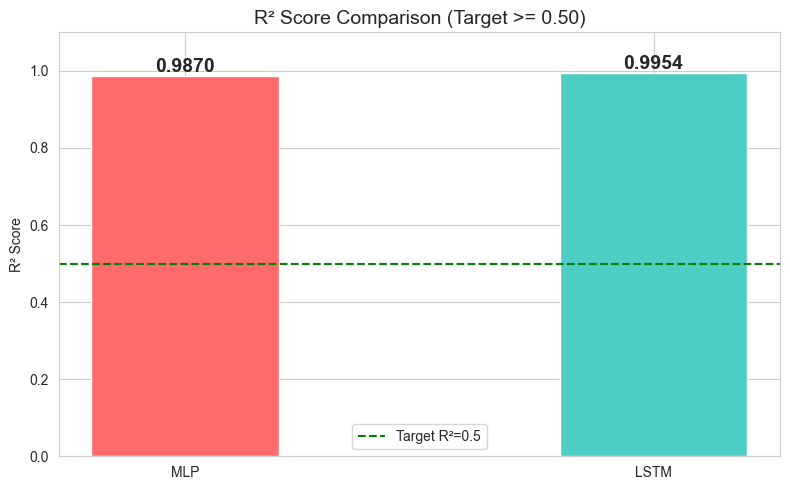

In [7]:
# ==================== 6. R² 对比柱状图 ====================
fig, ax = plt.subplots(figsize=(8, 5))
models_r = ['MLP', 'LSTM']
r2s = [r2_mlp, r2_lstm]
bars = ax.bar(models_r, r2s, color=['#FF6B6B','#4ECDC4'], edgecolor='white', width=0.4)
for b, v in zip(bars, r2s): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=14)
ax.axhline(y=0.5, color='green', linestyle='--', label='Target R²=0.5'); ax.legend()
ax.set_ylabel('R² Score'); ax.set_title('R² Score Comparison (Target >= 0.50)', fontsize=14); ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'regression_model', 'checkpoints', '03_r2_compare.png'), dpi=150, bbox_inches='tight')
plt.show()


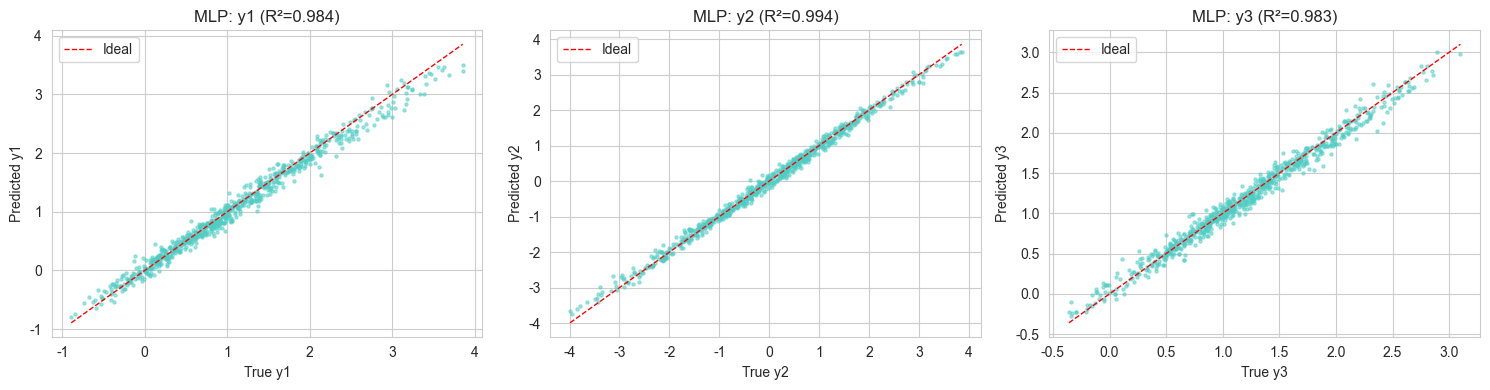

In [8]:
# ==================== 7. 预测 vs 真实值散点图 (MLP) ====================
Y_pred_orig = scaler_Y.inverse_transform(preds_mlp)
Y_true_orig = scaler_Y.inverse_transform(truths)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.scatter(Y_true_orig[:,i], Y_pred_orig[:,i], c='#4ECDC4', s=5, alpha=0.5)
    ax.plot([Y_true_orig[:,i].min(), Y_true_orig[:,i].max()],
            [Y_true_orig[:,i].min(), Y_true_orig[:,i].max()], 'r--', lw=1, label='Ideal')
    ax.set_xlabel(f'True y{i+1}'); ax.set_ylabel(f'Predicted y{i+1}')
    ax.set_title(f'MLP: y{i+1} (R²={r2_score(Y_true_orig[:,i], Y_pred_orig[:,i]):.3f})'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'regression_model', 'checkpoints', '04_pred_vs_true.png'), dpi=150, bbox_inches='tight')
plt.show()


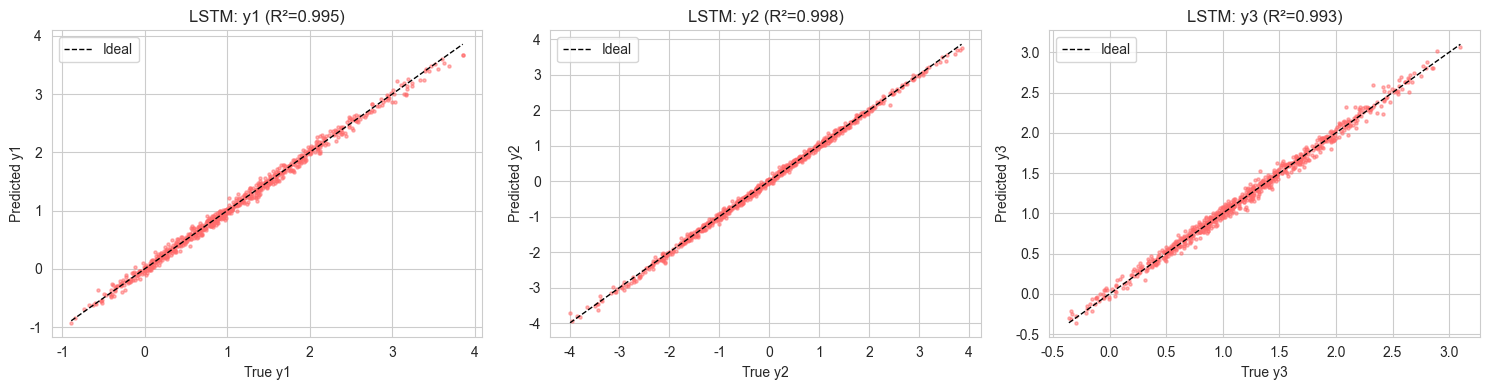


===== MLP vs LSTM 对比 (同一 3→3 数据) =====
MLP   | R²=0.9870  MSE=0.0125
LSTM  | R²=0.9954  MSE=0.0044
  y1: MLP R²=0.9838 | LSTM R²=0.9951
  y2: MLP R²=0.9938 | LSTM R²=0.9981
  y3: MLP R²=0.9833 | LSTM R²=0.9929


In [9]:
# ==================== 8. LSTM 预测 vs 真实值（同 MLP 对比） ====================
# 反标准化到原始尺度
Y_pred_lstm_orig = scaler_Y.inverse_transform(preds_lstm)
Y_true_orig_l = scaler_Y.inverse_transform(truths_l)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.scatter(Y_true_orig_l[:, i], Y_pred_lstm_orig[:, i], c='#FF6B6B', s=5, alpha=0.5)
    ax.plot([Y_true_orig_l[:, i].min(), Y_true_orig_l[:, i].max()],
            [Y_true_orig_l[:, i].min(), Y_true_orig_l[:, i].max()], 'k--', lw=1, label='Ideal')
    ax.set_xlabel(f'True y{i+1}'); ax.set_ylabel(f'Predicted y{i+1}')
    ax.set_title(f'LSTM: y{i+1} (R²={r2_score(Y_true_orig_l[:,i], Y_pred_lstm_orig[:,i]):.3f})')
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'regression_model', 'checkpoints', '05_lstm_results.png'), dpi=150, bbox_inches='tight')
plt.show()

# MLP vs LSTM 综合对比
print(f'\n===== MLP vs LSTM 对比 (同一 3→3 数据) =====')
print(f'MLP   | R²={r2_mlp:.4f}  MSE={mse_mlp:.4f}')
print(f'LSTM  | R²={r2_lstm:.4f}  MSE={mse_lstm:.4f}')
for i in range(3):
    r2_mlp_i = r2_score(truths[:, i], preds_mlp[:, i])
    r2_lstm_i = r2_score(truths_l[:, i], preds_lstm[:, i])
    print(f'  y{i+1}: MLP R²={r2_mlp_i:.4f} | LSTM R²={r2_lstm_i:.4f}')


In [10]:
# ==================== 9. 保存模型（MLP & LSTM 共用同一 scaler） ====================
CKPT = os.path.join(ROOT, 'backend', 'regression_model', 'checkpoints')
torch.save({
    'mlp_state_dict': {k: v.cpu().clone() for k, v in mlp_r.state_dict().items()},
    'lstm_state_dict': {k: v.cpu().clone() for k, v in lstm_r.state_dict().items()},
    'r2_mlp': r2_mlp, 'mse_mlp': mse_mlp,
    'r2_lstm': r2_lstm, 'mse_lstm': mse_lstm,
    'scaler_X': scaler_X, 'scaler_Y': scaler_Y,  # MLP & LSTM 共用
    'input_dim': 3, 'output_dim': 3,
}, os.path.join(CKPT, 'best_model.pth'))
print(f'Saved. MLP R²={r2_mlp:.4f}(MSE={mse_mlp:.4f}) | LSTM R²={r2_lstm:.4f}(MSE={mse_lstm:.4f})')


Saved. MLP R²=0.9870(MSE=0.0125) | LSTM R²=0.9954(MSE=0.0044)
